In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
import matplotlib.cm as cm

In [12]:
basePath = '/public/home/zju_visitor/LiuYuanhao/tng_data/output'
snapNum = 33

subhalo_fields = ['SubhaloSFR', 'SubhaloMassType']
subhalo_ids = il.groupcat.loadSubhalos(basePath, snapNum, fields=subhalo_fields)

subhalo_ids.keys()

dict_keys(['count', 'SubhaloSFR', 'SubhaloMassType'])

In [13]:
mass_stars_Msun = subhalo_ids['SubhaloMassType'][:, 4] * 1e10 / 0.6774
sfr_Msun_yr = subhalo_ids['SubhaloSFR']

valid_mask = (mass_stars_Msun > 0) & (sfr_Msun_yr > 0)

sSFR = sfr_Msun_yr[valid_mask] / mass_stars_Msun[valid_mask]

log_sSFR = np.log10(sSFR)
log_M_star = np.log10(mass_stars_Msun[valid_mask])

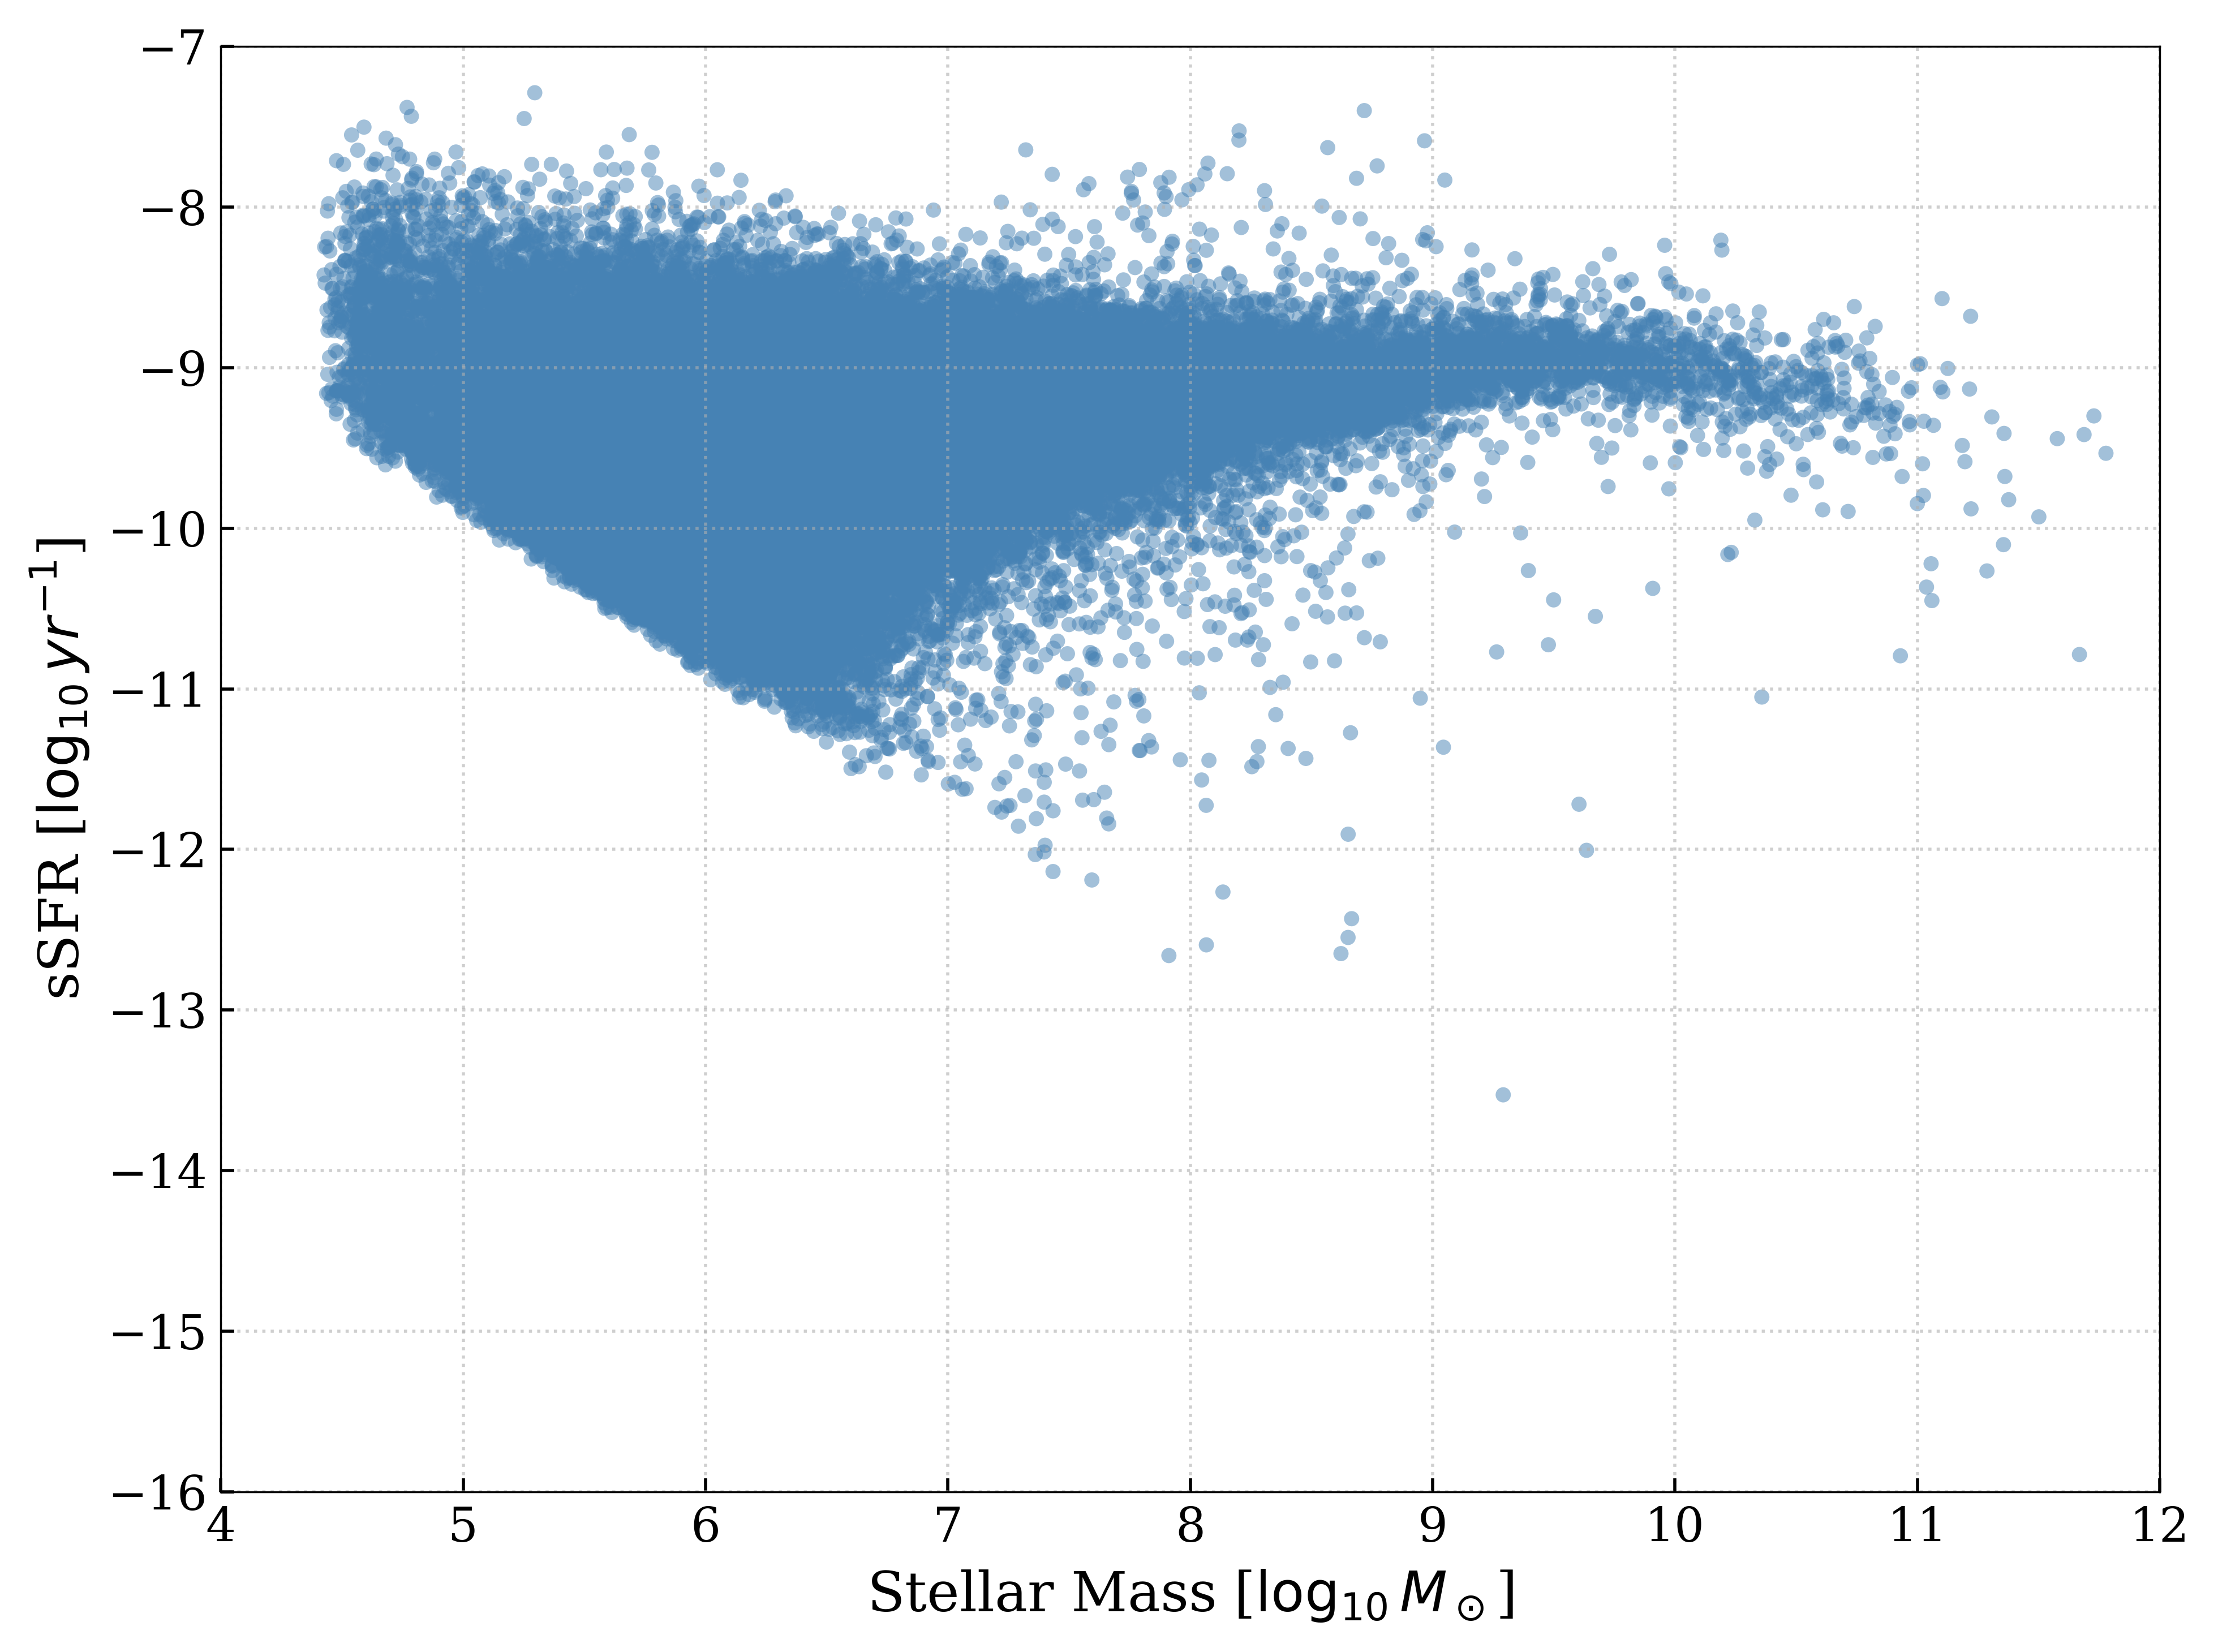

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(log_M_star, log_sSFR, color='steelblue', 
           s=15, alpha=0.5, edgecolors='none')

ax.set_xlabel('Stellar Mass [$\\log_{10} M_\\odot$]', fontsize=14)
ax.set_ylabel('sSFR [$\\log_{10} yr^{-1}$]', fontsize=14)

ax.set_xlim(4, 12)  
ax.set_ylim(-16, -7)  

ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [2]:
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 12
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['legend.fontsize'] = 10
rcParams['figure.dpi'] = 500  

In [3]:
def periodic_displacement(pos, center, BoxSize):
    """周期性边界条件"""
    return (pos - center + 0.5 * BoxSize) % BoxSize - 0.5 * BoxSize

def compute_temperature(u, ne, XH=0.76):
    """计算温度"""
    k_B = 1.38064852e-16  
    m_p = 1.6726219e-24   
    gamma = 5.0 / 3.0     
    u_cgs = u * 1e10
    mu = 4.0 / (1.0 + 3.0 * XH + 4.0 * XH * ne)
    T = (gamma - 1.0) * u_cgs * mu * m_p / k_B
    return T

def load_stream_data(subhalo_id, snapNum, cutout_dir, stream_dir):
    """读取数据"""
    cutout_file = os.path.join(cutout_dir, f"cutout_snap{snapNum:03d}_sh{subhalo_id}.hdf5")
    stream_file = os.path.join(stream_dir, f"cold_streams_snap{snapNum:03d}_sh{subhalo_id}.hdf5")

    if not os.path.exists(cutout_file) or not os.path.exists(stream_file):
        raise FileNotFoundError(f"Missing data for Subhalo {subhalo_id}.")

    data = {}
    with h5py.File(stream_file, 'r') as f:
        count = f['objects/count'][()]
        if count == 0:
            return None 
            
        data['count'] = count
        data['cell_inds'] = f['objects/cell_inds'][()]
        data['lengths'] = f['objects/lengths'][()]
        data['offsets'] = f['objects/offsets'][()]
        data['center_pos'] = f.attrs['CenterPos']
        data['r200c'] = f.attrs['R200c']
        data['ab_ratios'] = f['props/axis_ratio_ab'][()] if 'props/axis_ratio_ab' in f else np.zeros(count)

    with h5py.File(cutout_file, 'r') as f:
        pos_all = f['PartType0/Coordinates'][()]
        mass_all = f['PartType0/Masses'][()]
        
        if 'PartType0/InternalEnergy' in f and 'PartType0/ElectronAbundance' in f:
            u_all = f['PartType0/InternalEnergy'][()]
            ne_all = f['PartType0/ElectronAbundance'][()]
            temp_all = compute_temperature(u_all, ne_all)
        else:
            raise KeyError("Cutout 中缺乏计算温度所需的字段。")

        data['stream_pos'] = pos_all[data['cell_inds']]
        data['stream_mass'] = mass_all[data['cell_inds']]
        data['stream_temp'] = temp_all[data['cell_inds']]

    return data

In [4]:
def plot_cold_streams(subhalo_id, snapNum, cutout_dir, stream_dir, boxSize=35000.0, save_path=None):
    """生成 3D 冷流图"""
    
    try:
        data = load_stream_data(subhalo_id, snapNum, cutout_dir, stream_dir)
        if data is None:
            print(f"Subhalo {subhalo_id} 没有提取到冷流。")
            return
    except Exception as e:
        print(f"Error: {e}")
        return

    dx = periodic_displacement(data['stream_pos'], data['center_pos'], boxSize)

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 颜色映射
    norm = LogNorm(vmin=5e3, vmax=2.5e5) 
    cmap = plt.get_cmap('magma')
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 

    for i in range(data['count']):
        loc = slice(data['offsets'][i], data['offsets'][i] + data['lengths'][i])
        clump_dx = dx[loc]
        clump_temp = data['stream_temp'][loc]
        clump_mass = data['stream_mass'][loc]
        
        label_str = f"Stream {i+1} (a/b={data['ab_ratios'][i]:.1f})" if data['ab_ratios'][i] > 0 else f"Stream {i+1}"
        
        c_mapped = clump_temp 
        
        # 绘制散点
        ax.scatter(clump_dx[:, 0], clump_dx[:, 1], clump_dx[:, 2],
                   s=1.2,              
                   alpha=0.5,          
                   c=c_mapped,
                   cmap=cmap if isinstance(c_mapped, np.ndarray) else None, 
                   norm=norm if isinstance(c_mapped, np.ndarray) else None,
                   label=label_str,
                   edgecolors='none',
                   rasterized=True)

    
    rvir = data['r200c']

    shells = [
        {'r': 0.15 * rvir, 'color': 'darkred', 'ls': '-',  'alpha': 0.15, 'label': r'$0.15 R_{\rm vir}$'},
        {'r': rvir,        'color': 'darkblue', 'ls': '-', 'alpha': 0.10, 'label': r'$R_{\rm vir}$'},
    ]

    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]

    for shell in shells:
        x_sphere = shell['r'] * np.cos(u) * np.sin(v)
        y_sphere = shell['r'] * np.sin(u) * np.sin(v)
        z_sphere = shell['r'] * np.cos(v)
        
        ax.plot_wireframe(x_sphere, y_sphere, z_sphere, 
                          color=shell['color'], 
                          alpha=shell['alpha'], 
                          linewidth=0.6, 
                          linestyle=shell['ls'],
                          label=shell['label'])

    limit = rvir  
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_zlim([-limit, limit])
    
    ax.set_xlabel('X (kpc/h)', labelpad=10)
    ax.set_ylabel('Y (kpc/h)', labelpad=10)
    ax.set_zlabel('Z (kpc/h)', labelpad=10)
    ax.set_title(f"Cold Streams \nSnap: {snapNum} | Subhalo: {subhalo_id}", pad=20, weight='bold')

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')
    ax.grid(color='gray', linestyle=':', alpha=0.2)

    # 添加 Colorbar
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.1, shrink=0.8)
    cbar.set_label(r'Gas Temperature $T$ [K]', rotation=270, labelpad=25)
    cbar.locator = LogLocator(base=10.0, numticks=5)
    cbar.formatter = LogFormatterSciNotation(10.0)
    cbar.update_ticks()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=500, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    else:
        plt.show()

In [5]:
subhalo_ids = [ 59075 ]

Figure saved to: cold_streams_sh59075_snap33.pdf


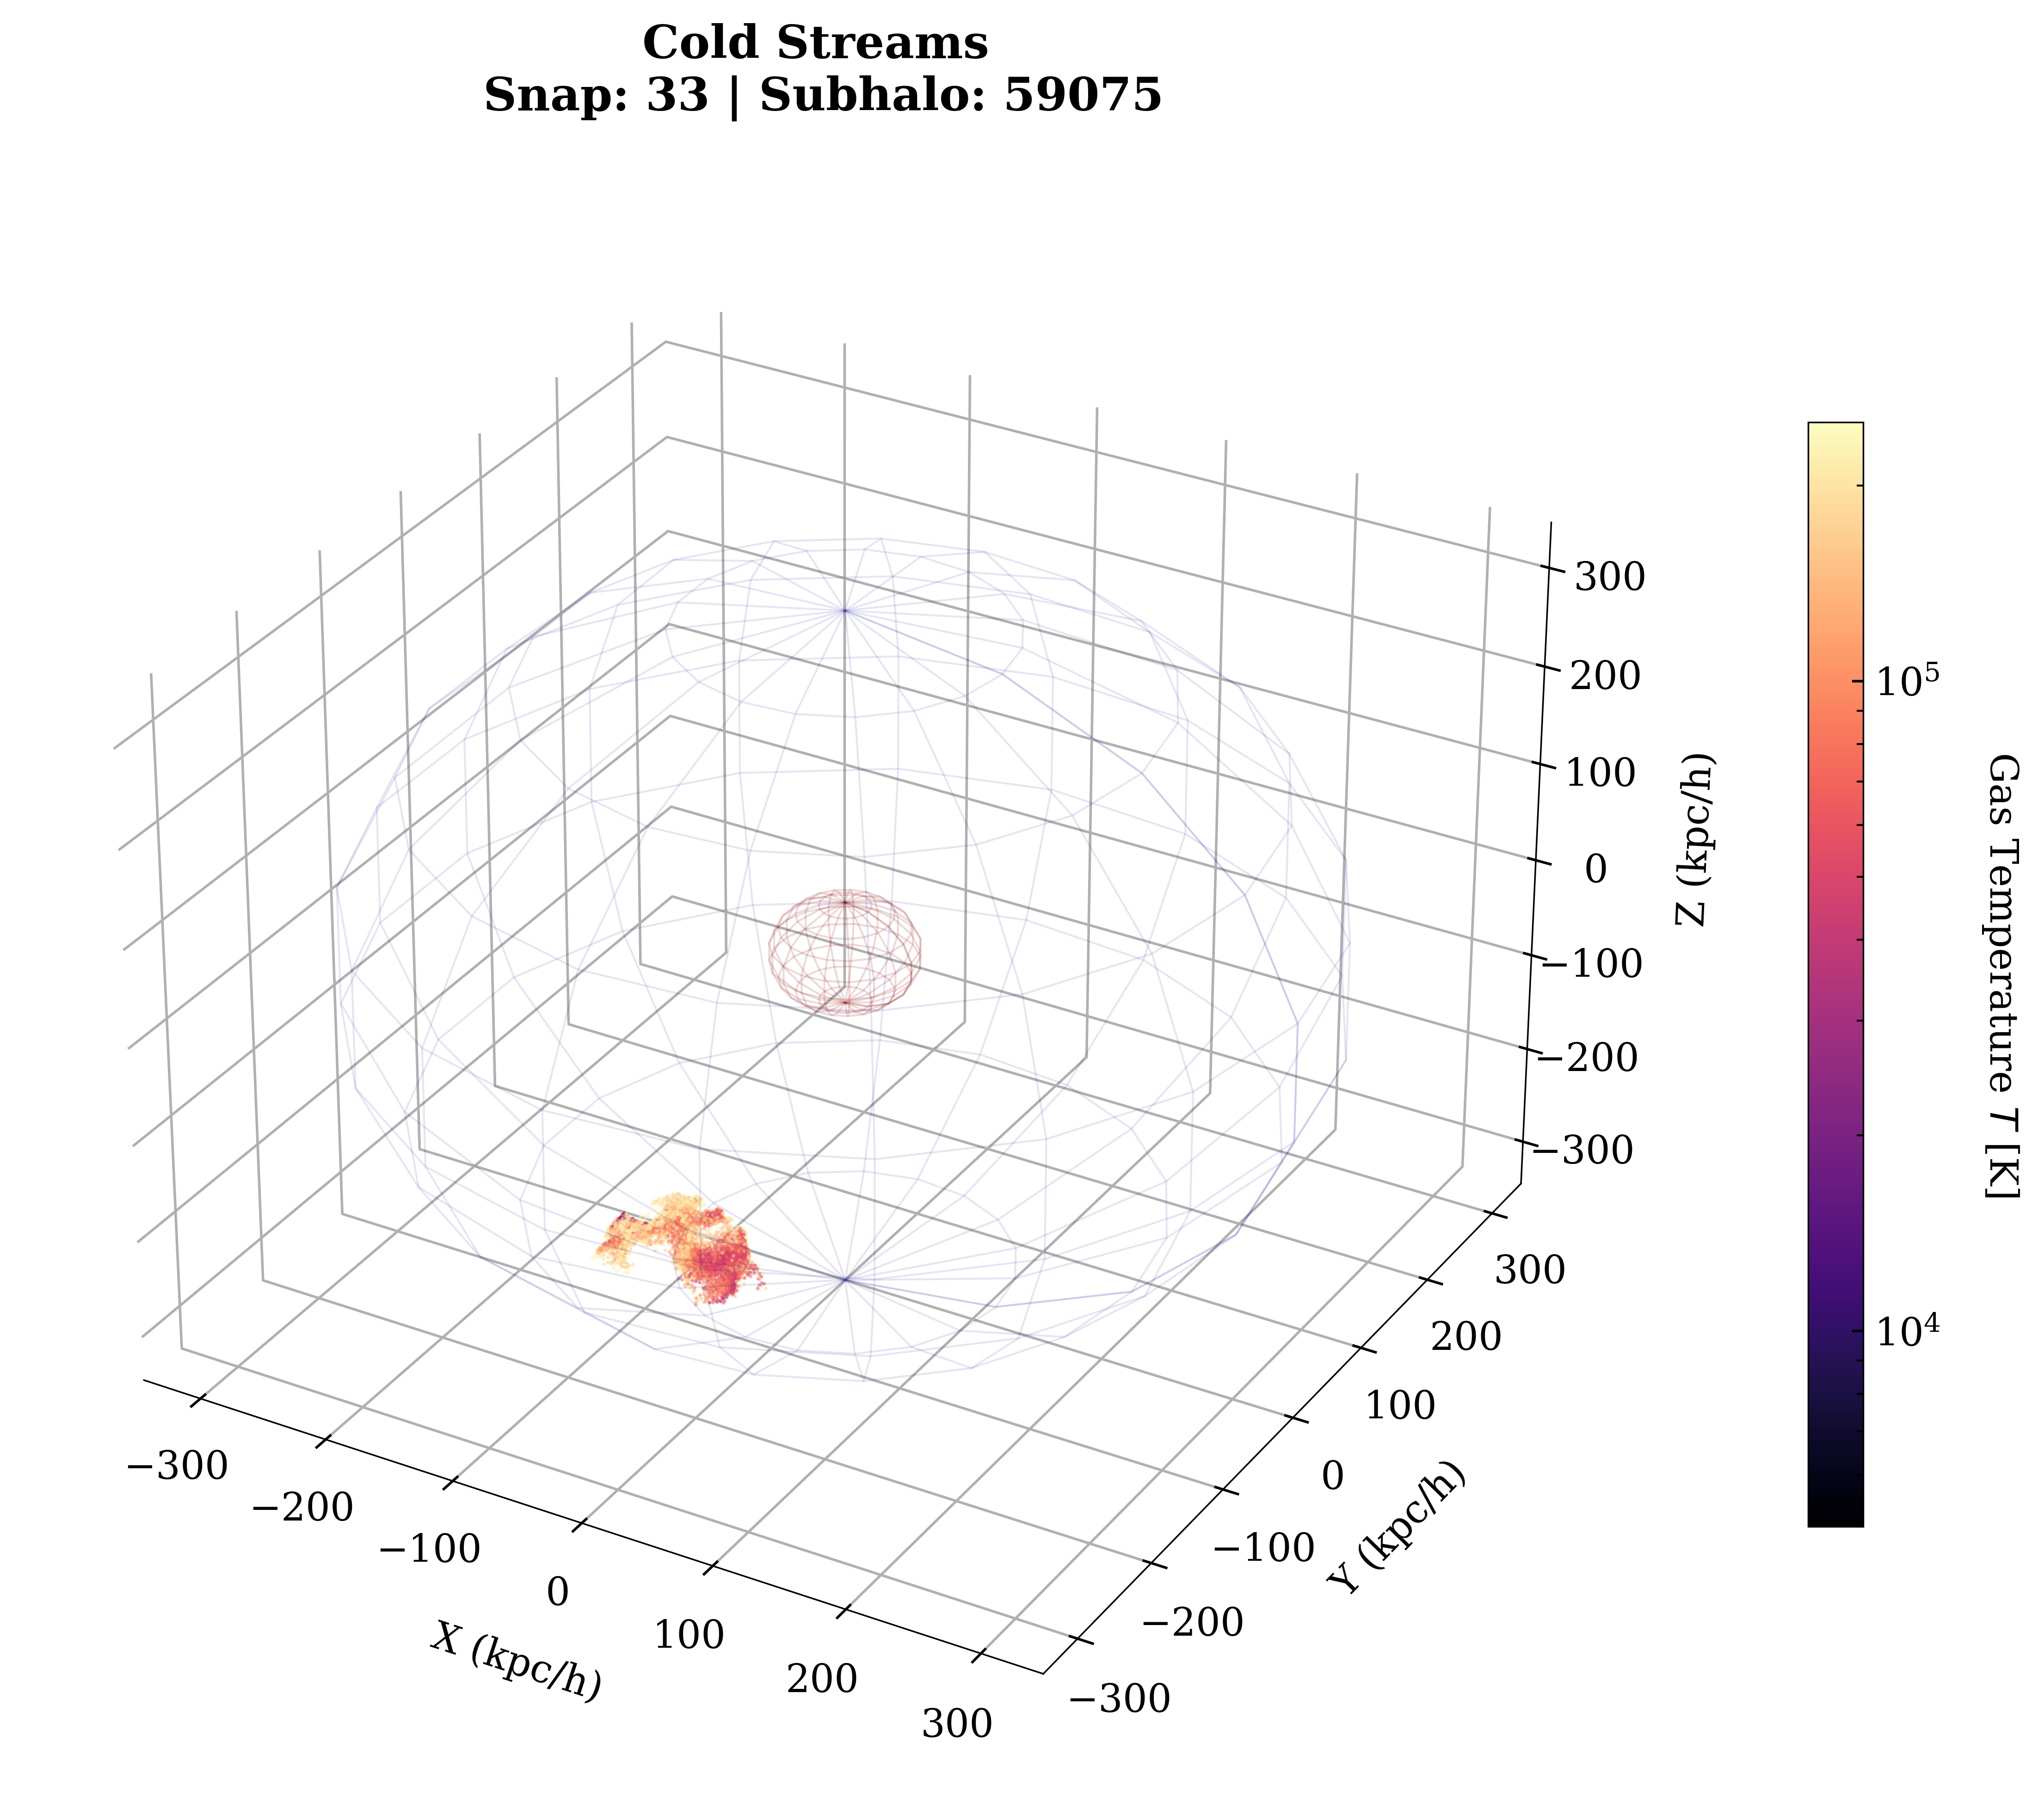

In [6]:
if __name__ == "__main__":
    cutout_dir = '/public/home/zju_visitor/LiuYuanhao/cold_stream/simulation_results/cutouts'
    stream_dir = '/public/home/zju_visitor/LiuYuanhao/cold_stream/simulation_results/streams'
    snapNum = 33
    BoxSize = 35000.0  
    
    for i in range(1):
        target_id = subhalo_ids[i]
        out_fig_path = f"cold_streams_sh{target_id}_snap{snapNum}.pdf"
        plot_cold_streams(target_id, snapNum, cutout_dir, stream_dir, BoxSize, save_path=out_fig_path)